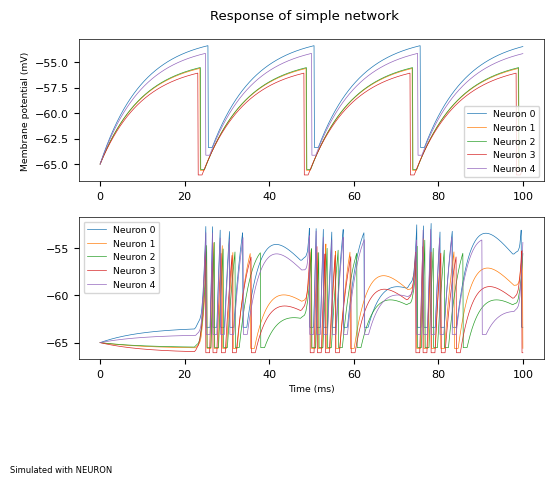

In [63]:
"""Simple network model using PyNN"""
import pyNN.neuron as sim
from pyNN.utility.plotting import Figure, Panel
from pyNN.random import RandomDistribution, NumpyRNG
sim.setup(timestep=0.1)
rng = NumpyRNG(seed=1)
cell_type  = sim.IF_curr_exp(
    v_rest=RandomDistribution('normal', mu=-65.0, sigma=1.0, rng=rng),
    v_thresh=RandomDistribution('normal', mu=-55.0, sigma=1.0, rng=rng),
    v_reset=RandomDistribution('normal', mu=-65.0, sigma=1.0, rng=rng), 
    tau_refrac=1, tau_m=10, cm=1, i_offset=1.1)
population1 = sim.Population(100, cell_type, label="Population 1")
population2 = sim.Population(100, cell_type, label="Population 2")
population2.set(i_offset=0)
population1.record("v")
population2.record("v")
connection_algorithm = sim.FixedProbabilityConnector(p_connect=0.5, rng=rng)
synapse_type = sim.StaticSynapse(weight=0.5, delay=0.5)
connections = sim.Projection(population1, population2, connection_algorithm, synapse_type)
sim.run(100.0)
data1_v = population1.get_data().segments[0].filter(name='v')[0]
data2_v = population2.get_data().segments[0].filter(name='v')[0]
Figure(
    Panel(
        data1_v[:, 0:5],
        xticks=True,
        yticks=True, ylabel="Membrane potential (mV)"
    ),
    Panel(
        data2_v[:, 0:5],
        xticks=True, xlabel="Time (ms)",
        yticks=True
    ),
    title="Response of simple network",
    annotations="Simulated with NEURON"
).show()

In [110]:
from nrnutils import Mechanism, Section

class SimpleNeuron(object):

    def __init__(self, **parameters):
        hh = Mechanism('hh', gl=parameters['g_leak'], el=-65, gnabar=parameters['gnabar'], gkbar=parameters['gkbar'])
        self.soma = Section(L=30, diam=30, mechanisms=[hh])
        self.initial_values = {"v": -65.0}

        #self.collateral = Section(L=500, diam=0.5, mechanisms=[hh], parent=self.soma)

        #self.collateral.insert("extracellular")

        # needed for PyNN
        self.source = {"soma": self.soma(0.5)._ref_v}
        self.source_section = {"soma": self.soma}
        self.parameter_names = ()
        self.traces = {}

In [111]:
from pyNN.neuron import NativeCellType

class SimpleNeuronType(NativeCellType):
    default_parameters = {'g_leak': 0.0002, 'gkbar': 0.036, 'gnabar': 0.12}
    default_initial_values = {'v': -65.0}
    recordable = ['soma(0.5).v', 'soma(0.5).ina']
    units = {'soma(0.5).v' : 'mV', 'soma(0.5).ina': 'nA'}
    receptor_types = ['soma.ampa']
    model = SimpleNeuron

In [93]:
class Sphere():
    def __init__(self, radius):
        self.radius = radius
                
    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the sphere with encapsulation layer"""
        num_points = n
        
        x_points = [] 
        y_points = [] 
        z_points = [] 
        
        theta = np.random.uniform(0, 2 * np.pi, num_points) 
        phi = np.random.uniform(0, np.pi, num_points) 
        x_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))  
        y_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
            
        x_points = x_radius * np.sin(phi) * np.cos(theta)
        y_points = y_radius * np.sin(phi) * np.sin(theta) 
        z_points = z_radius * np.cos(phi)

                   
        for idy, j in enumerate(y_points):
            invalid_y = (-1500 < j) and (j < 2000)
            while invalid_y:
                theta = np.random.uniform(0, 2 * np.pi) 
                phi = np.random.uniform(0, np.pi) 
                y_radius = 2000*np.cbrt(np.random.uniform(0, 1))
                j = y_radius * np.sin(phi) * np.sin(theta) 
                invalid_y = (-1500 < j) and (j < 2000)
            y_points[idy] = j


        for idx, i in enumerate(x_points):
            invalid_x = (-500 < i) and (i < 500)
            while invalid_x:
                theta = np.random.uniform(0, 2 * np.pi) 
                phi = np.random.uniform(0, np.pi) 
                x_radius = 2000*np.cbrt(np.random.uniform(0, 1))
                i = x_radius * np.sin(phi) * np.cos(theta) 
                invalid_x = (-500 < i) and (i < 500)
            x_points[idx] = i

        return x_points, y_points, z_points

In [94]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

v_init = -68
rng_seed = 856
n = 100
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode = np.array([11600,-16200,-9100])/1000
encapsulation = 1.135


############ Setup the simulation##########
sim.setup(timestep=0.01)

########## create a population of neurons ###############
cortical_pop = sim.Population(n, SimpleNeuronType())

ellipse = Sphere(2000)
cortical_space = ellipse.generate_positions(n)
cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[0]/1000, cortical_space[1]/1000, cortical_space[2]/1000

In [95]:
voltage_file = pd.read_csv(
    "../MDT3389_Mesh2_050126_E3_BSGrid.txt",
    sep=r"\s+",
    header=None,
    names=["x", "y", "z", "V"]
)

#translate the center to the center we have already identified - no need to translate the sphere since it is already centered at (0,0,0)
x_voltage_coordinates = voltage_file['x'].values
y_voltage_coordinates = voltage_file['y'].values
z_voltage_coordinates = voltage_file['z'].values-6.25

#convert to mV since NEURON and PyNN use mV
voltages = voltage_file['V'].values*1000

points = np.array([x_voltage_coordinates,y_voltage_coordinates,z_voltage_coordinates]).T

In [96]:
 Vint = LinearNDInterpolator(points, voltages)

In [97]:
x_points_ctx = cortical_pop.positions[0]
y_points_ctx = cortical_pop.positions[1]
z_points_ctx = cortical_pop.positions[2]
interpolated_values_ctx = Vint(np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx)))
efield = np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx,interpolated_values_ctx))

In [114]:
for cell in cortical_pop:
    test = (cell.position == efield[:, :-1])
    indices = np.where(np.all(test, axis=1))[0]
    indices = int(indices[0])
    cell.e_extracellular = efield[indices, 3]
    #print(cell, cell.position, indices, cell.e_extracellular)

In [102]:
for cell in cortical_pop:
    print(cell.collateral)

AttributeError: 'SimpleNeuron' object has no attribute 'g_leak'